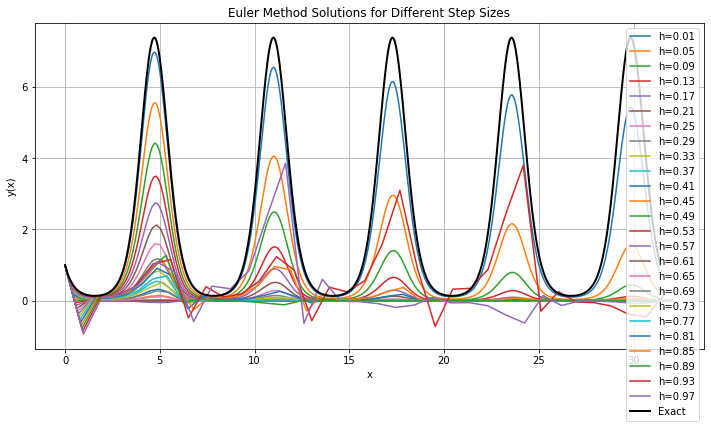

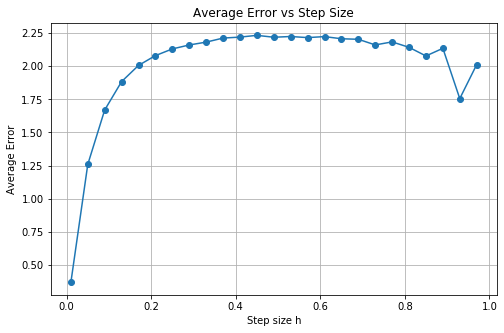

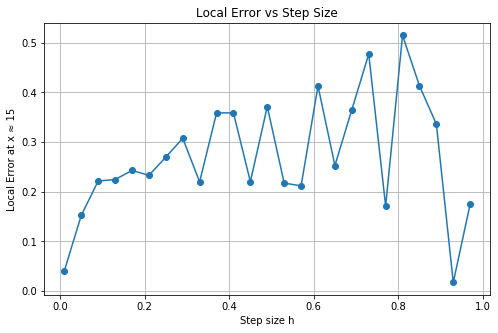

In [2]:
import numpy as np
import matplotlib.pyplot as plt


#Setup

def f(x, y):
    return -2 * y * np.cos(x)

def y_exact(x):
    return np.exp(-2 * np.sin(x))

h_values = np.arange(0.01, 1.0, 0.04)  # [.01, .05, .15, ... <1]
x_end = 10 * np.pi

x_target = 15  # for local error comparison

solutions = []
avg_errors = []
local_errors = []

plt.figure(figsize=(12, 6))


#Euler runs for each h

for h in h_values:

    x_vals = np.arange(0, x_end + h, h)
    y_vals = np.zeros(len(x_vals))
    y_vals[0] = 1.0

    #Euler method
    for i in range(1, len(x_vals)):
        y_vals[i] = y_vals[i - 1] + h * f(x_vals[i - 1], y_vals[i - 1])

    #store solution
    solutions.append((h, x_vals, y_vals))

    #exact values at same grid
    y_true = y_exact(x_vals)

    #average error
    avg_err = np.mean(np.abs(y_vals - y_true))
    avg_errors.append(avg_err)

    #local error near x ≈ 15
    idx = np.argmin(np.abs(x_vals - x_target))
    local_err = abs(y_vals[idx] - y_true[idx])
    local_errors.append(local_err)

    #plot solution
    plt.plot(x_vals, y_vals, label=f"h={h:.2f}")


#Plot 1: Euler solutions

plt.plot(np.linspace(0, x_end, 1000),
         y_exact(np.linspace(0, x_end, 1000)),
         'k', linewidth=2, label="Exact")

plt.xlabel("x")
plt.ylabel("y(x)")
plt.title("Euler Method Solutions for Different Step Sizes")
plt.legend()
plt.grid()
plt.show()


#Plot 2: Average error vs h

plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size")
plt.grid()
plt.show()


#Plot 3: Local error at x≈15

plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Local Error at x ≈ 15")
plt.title("Local Error vs Step Size")
plt.grid()
plt.show()

In [ ]:
#In the first plot, the smaller h values stick to the exact graph closer, but still lose some accuracy over time
#This effec gets worse and worse and worse as h increases, with seemingly random spikes and jumps beginning to
#affect the larger h plots. This is because larger step sizes fail to accurately keep up with the graph due to low 
#resolution and compounding error

#In the second plot, we see the average error jump rapidly, decrease slightly, and finally begin to oscillate. The first jump
#is again due to the low step sizes failing to generate enough points to follow the function and leading to compounding error,
#and eventually errors in phase shift can lead to oscillating error magnitutes

#The third plot demonstrates the principle from the second plot even better, where some h values are out of phase
#while others are in phase to to compounding error, leading to error oscillating at greater and greater magnitudes